In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv("pulsar_data_train.csv")

In [65]:
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0


In [66]:
df.tail()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
12523,124.312500,53.179053,-0.012418,-0.556021,7.186455,29.308266,4.531382,21.725143,0.0
12524,115.617188,46.784600,0.218177,0.226757,6.140468,NaN,5.732201,34.357283,0.0
12525,116.031250,43.213846,0.663456,0.433088,0.785117,11.628149,17.055215,312.204325,0.0
12526,135.664062,49.933749,-0.089940,-0.226726,3.859532,21.501505,7.398395,62.334018,0.0
12527,120.726562,50.472256,0.346178,0.184797,0.769231,11.792603,17.662222,329.548016,0.0


In [67]:
df.shape

(12528, 9)

In [68]:
df.isnull().sum()

 Mean of the integrated profile                     0
 Standard deviation of the integrated profile       0
 Excess kurtosis of the integrated profile       1735
 Skewness of the integrated profile                 0
 Mean of the DM-SNR curve                           0
 Standard deviation of the DM-SNR curve          1178
 Excess kurtosis of the DM-SNR curve                0
 Skewness of the DM-SNR curve                     625
target_class                                        0
dtype: int64

In [69]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [70]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [71]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [72]:
df.isnull().sum()

 Mean of the integrated profile                  0
 Standard deviation of the integrated profile    0
 Excess kurtosis of the integrated profile       0
 Skewness of the integrated profile              0
 Mean of the DM-SNR curve                        0
 Standard deviation of the DM-SNR curve          0
 Excess kurtosis of the DM-SNR curve             0
 Skewness of the DM-SNR curve                    0
target_class                                     0
dtype: int64

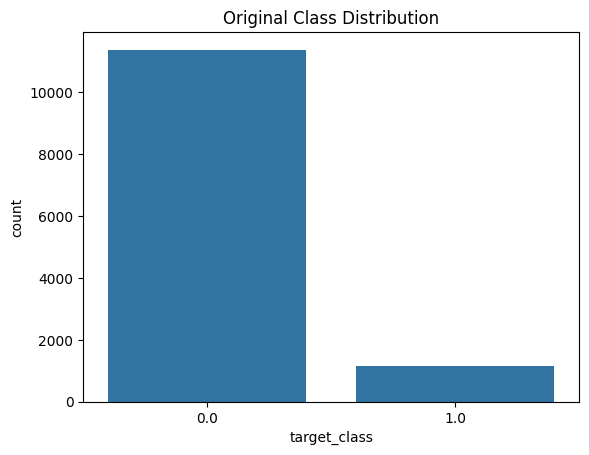

In [73]:
sns.countplot(x='target_class', data=df)
plt.title("Original Class Distribution")
plt.show()

The original dataset is imbalanced.

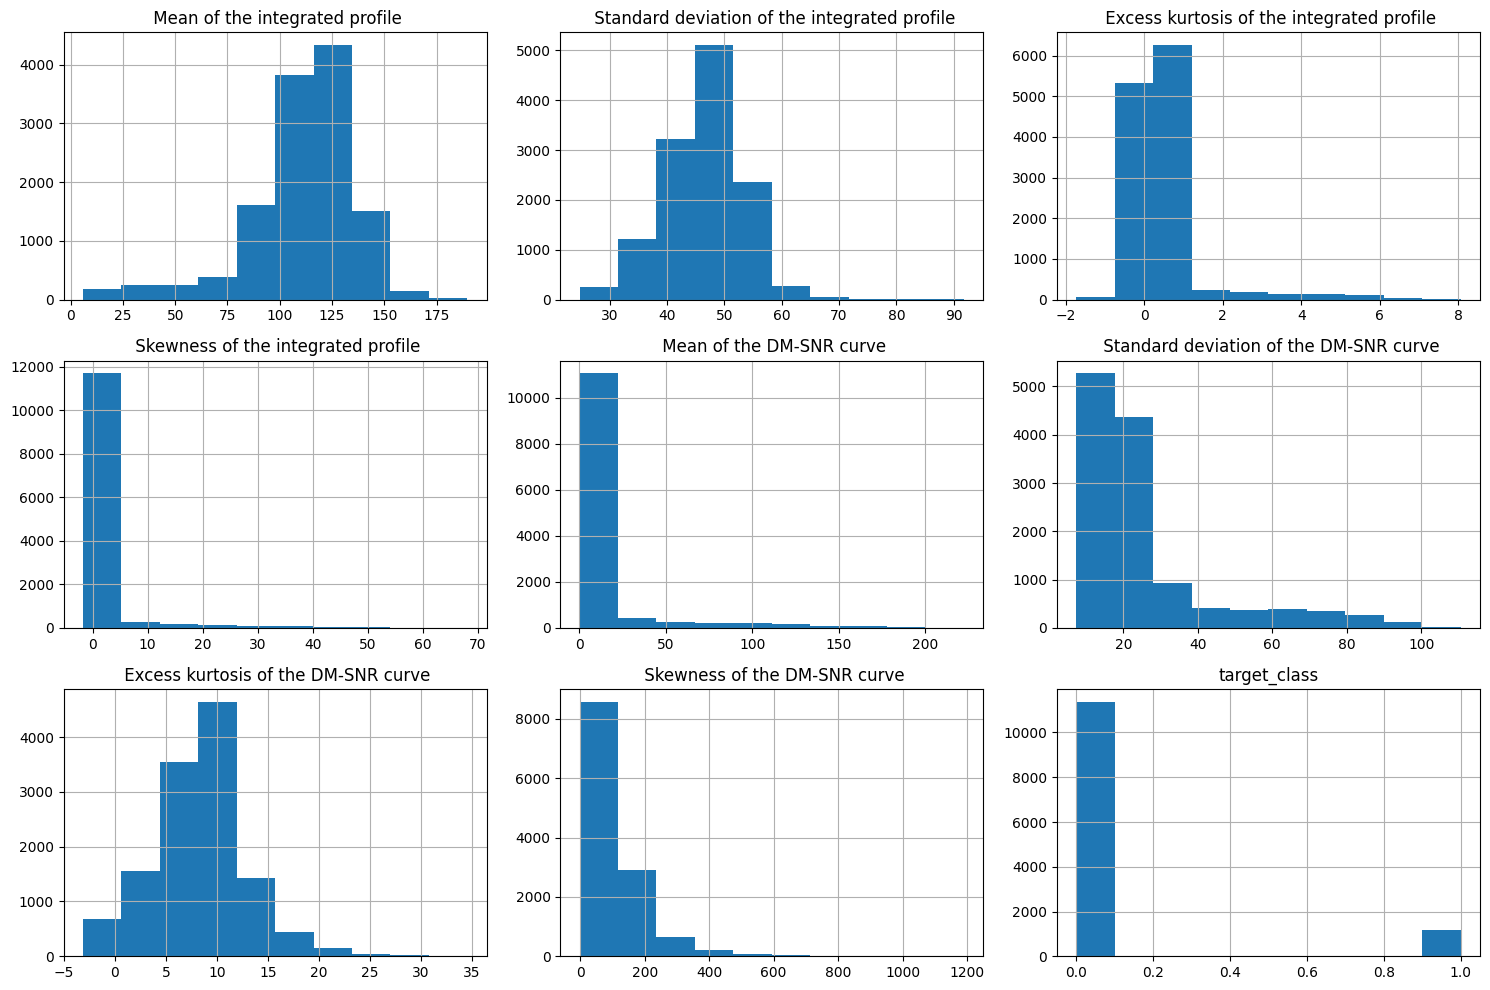

In [74]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

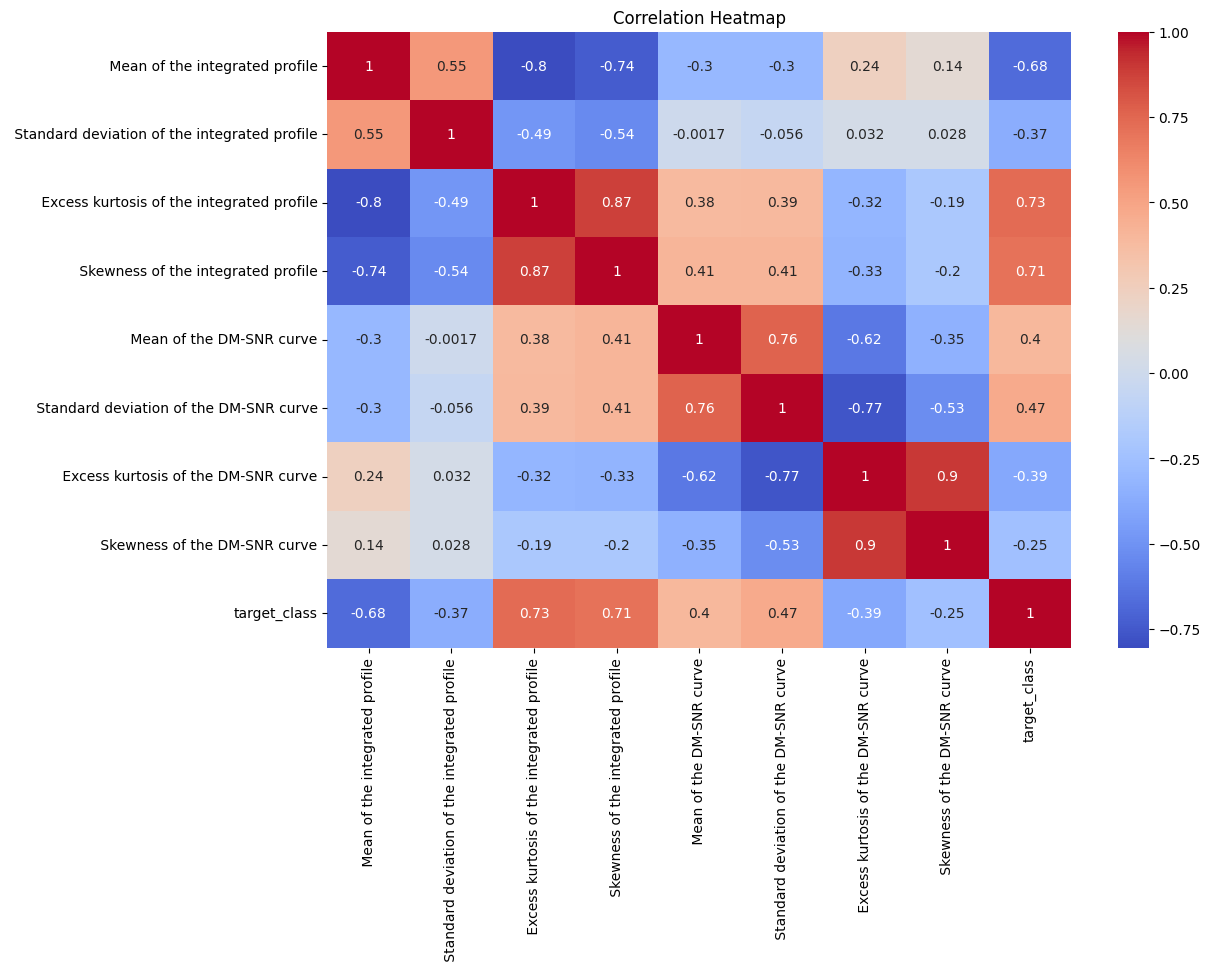

In [75]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm',annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [76]:
new_df = (
    df.groupby('target_class')
      .sample(n=1100, random_state=42)
      .reset_index(drop=True)
)

Balancing the dataset with 1100 samples of each target.

In [77]:
new_df['target_class'].value_counts()

target_class
0.0    1100
1.0    1100
Name: count, dtype: int64

In [78]:
new_df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,90.125000,42.903416,0.694571,1.105028,2.301003,18.412402,9.050779,114.213809,0.0
1,112.398438,51.912839,0.078931,-0.243554,3.209866,20.413131,8.706795,84.093180,0.0
2,115.070312,48.212288,0.223678,0.153865,4.385452,26.986143,6.683398,45.698091,0.0
3,117.960938,51.588274,0.166451,-0.261494,3.161371,19.577516,7.604437,64.483369,0.0
4,127.265625,49.595628,0.026180,-0.095198,2.742475,15.365466,8.296467,90.681156,0.0


In [79]:
new_df.tail()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
2195,79.070312,43.383858,1.584940,3.885098,34.217391,64.417648,1.718283,1.680739,1.0
2196,65.578125,33.347275,2.351982,9.971398,6.403846,31.109903,5.646218,33.645504,1.0
2197,114.585938,59.537085,0.346221,-0.705473,3.777592,26.556163,7.749978,60.450599,1.0
2198,70.984375,47.462812,1.698130,3.342903,6.898829,30.634439,5.769658,35.776486,1.0
2199,48.000000,33.125236,3.232483,14.973286,69.980769,62.086980,0.678814,0.096656,1.0


In [80]:
new_df.describe()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,86.457614,43.017062,1.462193,7.882787,29.801512,38.190348,5.774340,65.524248,0.500000
std,38.461671,8.190563,1.900502,12.456544,42.162400,24.546233,4.801134,91.105498,0.500114
min,5.812500,24.772042,-1.118709,-1.334542,0.282609,7.565681,-2.282560,-1.931996,0.000000
25%,54.484375,36.824447,0.223678,0.092828,2.497910,17.796278,1.599598,1.877400,0.000000
50%,95.492188,43.478178,0.445335,1.295904,6.823997,27.734206,5.205490,34.273667,0.500000
75%,117.046875,49.152527,2.407940,11.142440,40.323370,60.619985,9.098021,91.810831,1.000000
max,167.593750,79.084407,8.069522,68.101622,200.500000,109.655345,32.198584,1072.957979,1.000000


In [81]:
new_df.isnull().sum()

 Mean of the integrated profile                  0
 Standard deviation of the integrated profile    0
 Excess kurtosis of the integrated profile       0
 Skewness of the integrated profile              0
 Mean of the DM-SNR curve                        0
 Standard deviation of the DM-SNR curve          0
 Excess kurtosis of the DM-SNR curve             0
 Skewness of the DM-SNR curve                    0
target_class                                     0
dtype: int64

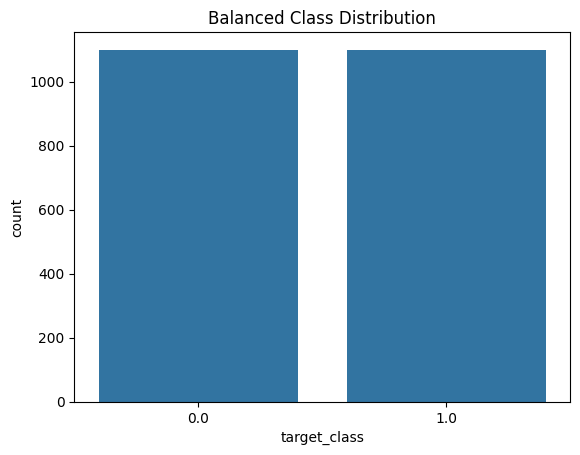

In [82]:
sns.countplot(x='target_class', data=new_df)
plt.title("Balanced Class Distribution")
plt.show()


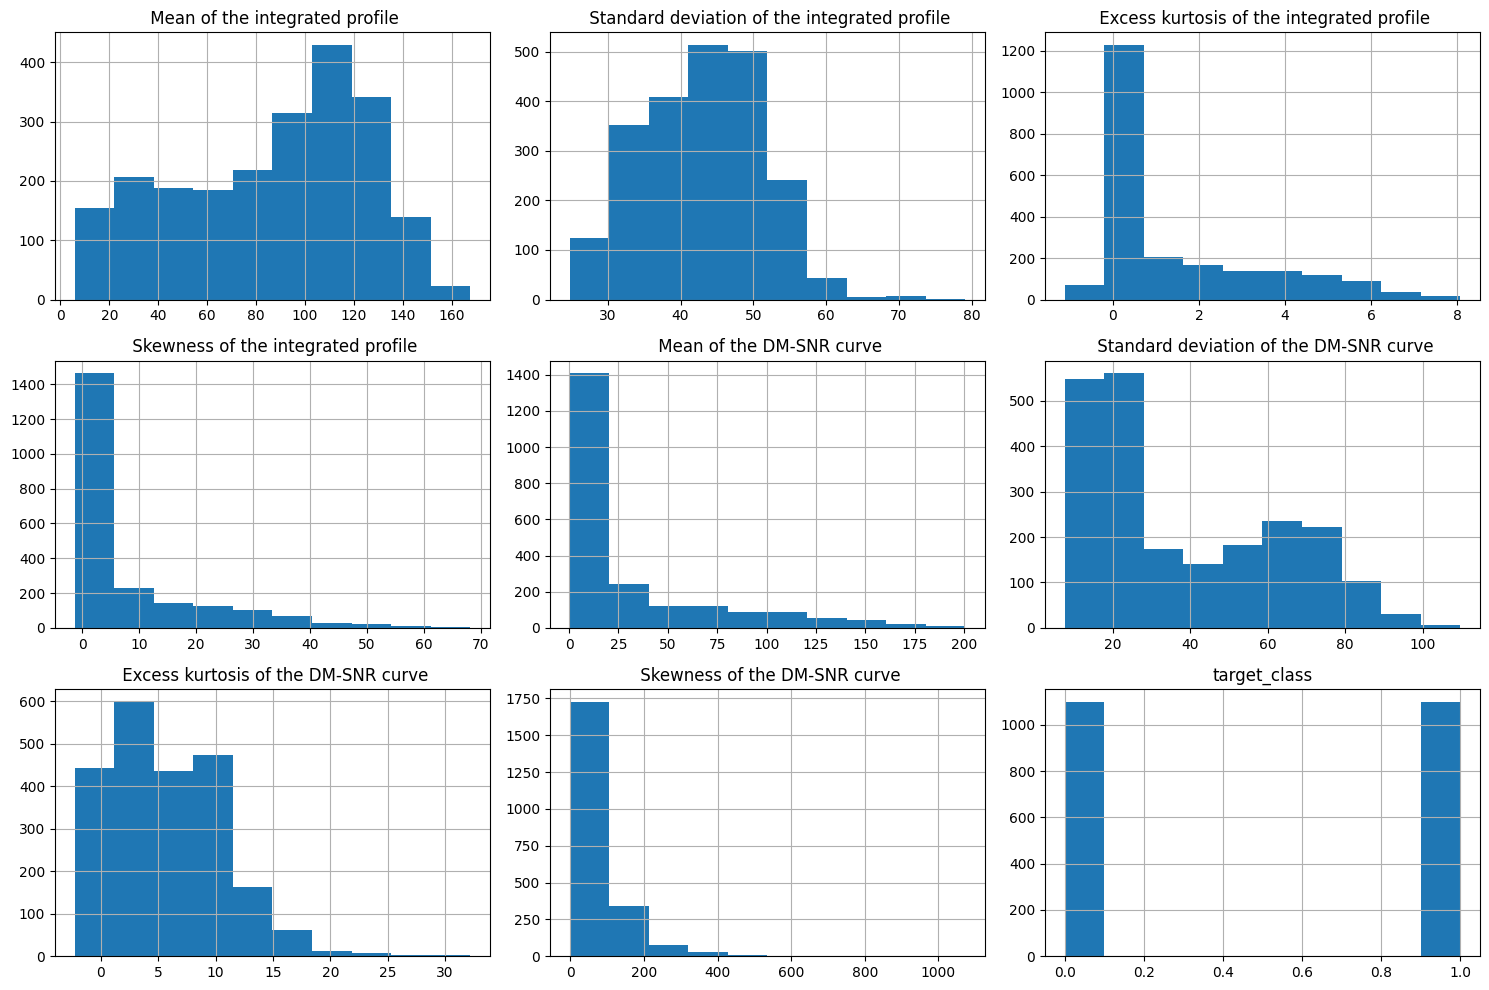

In [83]:
new_df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

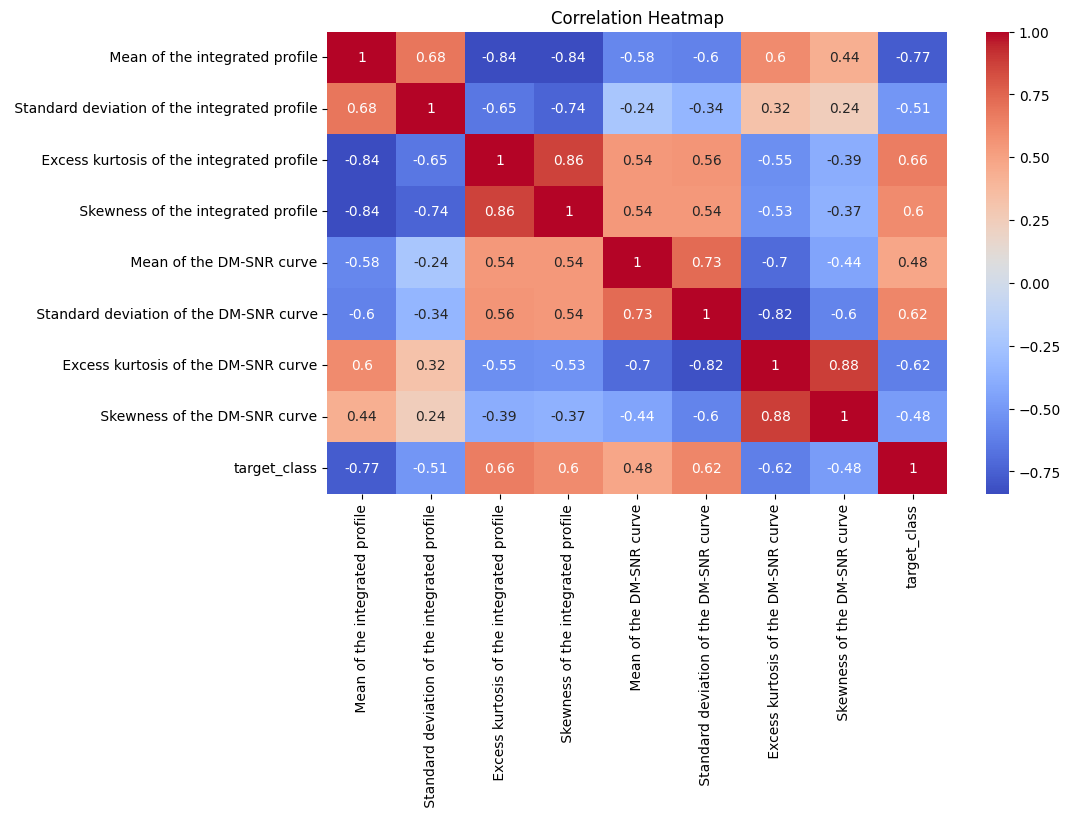

In [84]:
correlation = new_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation, cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap")
plt.show()


In [85]:
correlation['target_class'].sort_values(ascending=False)

target_class                                     1.000000
 Excess kurtosis of the integrated profile       0.659098
 Standard deviation of the DM-SNR curve          0.621028
 Skewness of the integrated profile              0.601902
 Mean of the DM-SNR curve                        0.478288
 Skewness of the DM-SNR curve                   -0.481225
 Standard deviation of the integrated profile   -0.513812
 Excess kurtosis of the DM-SNR curve            -0.619644
 Mean of the integrated profile                 -0.771963
Name: target_class, dtype: float64

In [86]:
X = new_df.drop(columns=['target_class'])
y = new_df['target_class']

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((1760, 8), (440, 8))

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,r2_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

model


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [95]:
print("Accuracy Score of Linear Regression:",accuracy_score(y_test, y_pred))

print("R2 Score of Linear Regression:", r2_score(y_test,y_pred))


Accuracy Score of Linear Regression: 0.925
R2 Score of Linear Regression: 0.7


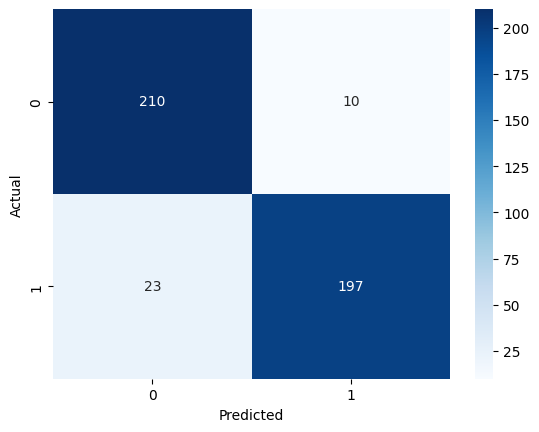

In [90]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [91]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.90      0.95      0.93       220
         1.0       0.95      0.90      0.92       220

    accuracy                           0.93       440
   macro avg       0.93      0.93      0.92       440
weighted avg       0.93      0.93      0.92       440

